# Entrenamiento del Denoising Autoencoder
## DAE-LSTM y DAE-GRU con Busqueda de Hiperparametros

**Proyecto:** Deteccion de Anomalias en Mercados Accionarios Colombianos mediante Deep Learning  
**Activos:** Ecopetrol (EC), Bancolombia (CIB), Grupo Aval (AVAL), Tecnoglass (TGLS)  
**Framework:** TensorFlow / Keras  
**Autores:** Mariana Franco — Danier Conde

---

### Estructura del Notebook

| Seccion | Contenido |
|---|---|
| 1 | Configuracion y carga de artefactos desde NB2 |
| 2 | Definicion de la arquitectura DAE-LSTM y DAE-GRU |
| 3 | Busqueda de hiperparametros sobre conjunto de validacion |
| 4 | Entrenamiento del modelo final con la mejor configuracion |
| 5 | Exportacion de modelos entrenados |

---

### Principios de entrenamiento

- El modelo se entrena exclusivamente sobre el conjunto de entrenamiento (2015-2019).
- El conjunto de validacion (2020) se usa unicamente para seleccionar la
  mejor configuracion de hiperparametros via MSE de reconstruccion.
- El conjunto de test (2021-2024) no se toca en este notebook.
- El criterio de seleccion es el MSE medio de reconstruccion sobre las
  ventanas del conjunto de validacion — no el loss de entrenamiento.
- DAE-LSTM y DAE-GRU compiten bajo protocolo identico. La variante con
  menor MSE en validacion se reporta como modelo final del proyecto.

---
## 1. Configuracion y Carga de Artefactos

In [8]:
import os
import pickle
import warnings
import itertools
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Rutas absolutas del proyecto
BASE_PATH    = Path(r'C:/2026-10/DEEP LEARNING/anomaly-detection-colombian-stocks-autoencoder')
DATA_PATH    = BASE_PATH / 'data'   / 'processed'
SCALERS_PATH = BASE_PATH / 'models' / 'scalers'
AE_PATH      = BASE_PATH / 'models' / 'autoencoder'
OUTPUTS_PATH = BASE_PATH / 'outputs'

AE_PATH.mkdir(parents=True, exist_ok=True)
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

# Parametros globales
TICKERS      = ['EC', 'CIB', 'AVAL', 'TGLS']
NAMES        = {'EC': 'Ecopetrol', 'CIB': 'Bancolombia',
                'AVAL': 'Grupo Aval', 'TGLS': 'Tecnoglass'}
FEATURE_COLS = ['log_return', 'vol_21d', 'vol_zscore']
SEQ_LEN      = 30
N_FEATURES   = len(FEATURE_COLS)

print('Configuracion cargada.')
print(f'  TensorFlow   : {tf.__version__}')
print(f'  GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'  Seed         : {SEED}')

Configuracion cargada.
  TensorFlow   : 2.21.0
  GPU disponible: False
  Seed         : 42


In [9]:
# Carga de tensores exportados por NB2
windows = {}
scalers = {}

for ticker in TICKERS:
    windows[ticker] = {}
    for split in ['train', 'val', 'test']:
        path = DATA_PATH / f'{ticker}_{split}_windows.npy'
        windows[ticker][split] = np.load(path)
    scaler_path = SCALERS_PATH / f'{ticker}_scaler.pkl'
    with open(scaler_path, 'rb') as f:
        scalers[ticker] = pickle.load(f)

# Verificacion de shapes
print('ARTEFACTOS CARGADOS')
print('=' * 65)
print(f"{'Activo':<14}  {'Train':>20}  {'Val':>20}  {'Test':>20}")
print('-' * 76)
for ticker in TICKERS:
    shapes = {s: windows[ticker][s].shape for s in ['train', 'val', 'test']}
    print(f"{NAMES[ticker]:<14}  "
          f"{str(shapes['train']):>20}  "
          f"{str(shapes['val']):>20}  "
          f"{str(shapes['test']):>20}")

print()
print(f'Shape esperado: (n_ventanas, {SEQ_LEN}, {N_FEATURES})')
print('Scalers cargados:', list(scalers.keys()))

ARTEFACTOS CARGADOS
Activo                         Train                   Val                  Test
----------------------------------------------------------------------------
Ecopetrol              (1208, 30, 3)          (224, 30, 3)          (975, 30, 3)
Bancolombia            (1208, 30, 3)          (224, 30, 3)          (975, 30, 3)
Grupo Aval             (1208, 30, 3)          (224, 30, 3)          (975, 30, 3)
Tecnoglass             (1149, 30, 3)          (224, 30, 3)          (975, 30, 3)

Shape esperado: (n_ventanas, 30, 3)
Scalers cargados: ['EC', 'CIB', 'AVAL', 'TGLS']


---
## 2. Arquitectura del Denoising Autoencoder

**Principio de operacion**

El DAE recibe una ventana de entrada perturbada con ruido gaussiano y es
entrenado para reconstruir la ventana original limpia. El encoder comprime
la secuencia en un vector latente de dimension `latent_dim`. El decoder
reconstruye la secuencia completa a partir de ese vector.

Durante la inferencia (deteccion de anomalias) el ruido NO se aplica.
El modelo recibe la ventana limpia y el MSE de reconstruccion es la
puntuacion de anomalia.

```
ENTRADA PERTURBADA: (batch, T=30, F=3)
       ↓
   ENCODER
   LSTM/GRU(64, return_sequences=True)  + Dropout
   LSTM/GRU(32, return_sequences=False) + Dropout
   Dense(latent_dim)                    → vector z
       ↓
   DECODER
   RepeatVector(30)
   LSTM/GRU(32, return_sequences=True)  + Dropout
   LSTM/GRU(64, return_sequences=True)  + Dropout
   TimeDistributed(Dense(3))            → reconstruccion
       ↓
SALIDA RECONSTRUIDA: (batch, T=30, F=3)
Objetivo: minimizar MSE(entrada_limpia, reconstruccion)
```

In [10]:
def build_dae(seq_len, n_features, latent_dim, dropout_rate,
              cell_type='LSTM', name='DAE'):
    """
    Construye un Denoising Autoencoder recurrente.

    El modelo recibe UNA sola entrada (la ventana perturbada con ruido).
    El ruido se aplica fuera del modelo antes de llamar a fit().
    El target de reconstruccion es la ventana limpia original.

    Parametros
    ----------
    seq_len      : int, longitud de la ventana temporal (T=30)
    n_features   : int, numero de features por timestep (F=3)
    latent_dim   : int, dimension del espacio latente {8, 16, 32}
    dropout_rate : float, tasa de dropout {0.1, 0.2, 0.3}
    cell_type    : str, 'LSTM' o 'GRU'
    name         : str, nombre del modelo

    Retorna
    -------
    keras.Model compilado con optimizador Adam y loss MSE
    """
    RNN = layers.LSTM if cell_type == 'LSTM' else layers.GRU

    # Una sola entrada: ventana (posiblemente perturbada)
    inputs = keras.Input(shape=(seq_len, n_features), name='input')

    # Encoder
    x = RNN(64, return_sequences=True,  name='enc_1')(inputs)
    x = layers.Dropout(dropout_rate,    name='drop_enc_1')(x)
    x = RNN(32, return_sequences=False,  name='enc_2')(x)
    x = layers.Dropout(dropout_rate,    name='drop_enc_2')(x)
    z = layers.Dense(latent_dim, activation='relu', name='latent')(x)

    # Decoder
    x = layers.RepeatVector(seq_len,    name='repeat')(z)
    x = RNN(32, return_sequences=True,  name='dec_1')(x)
    x = layers.Dropout(dropout_rate,    name='drop_dec_1')(x)
    x = RNN(64, return_sequences=True,  name='dec_2')(x)
    x = layers.Dropout(dropout_rate,    name='drop_dec_2')(x)
    outputs = layers.TimeDistributed(
        layers.Dense(n_features), name='output'
    )(x)

    model = Model(inputs=inputs, outputs=outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse'
    )
    return model


def compute_val_mse(model, X_val):
    """
    Calcula el MSE medio de reconstruccion sobre el conjunto de validacion.
    En inferencia se pasa la ventana limpia directamente (sin ruido).

    Retorna
    -------
    float: MSE medio sobre todas las ventanas de validacion
    """
    X_pred = model.predict(X_val, verbose=0)
    mse    = np.mean((X_val - X_pred) ** 2, axis=(1, 2))
    return float(np.mean(mse))



# Verificacion con configuracion base
model_test = build_dae(
    seq_len=SEQ_LEN, n_features=N_FEATURES,
    latent_dim=16, dropout_rate=0.2, cell_type='LSTM'
)
model_test.summary()
del model_test

Model: "DAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (LSTM)                    │ (None, 30, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_1 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (LSTM)                    │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_2 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (LSTM)                    │ (None, 30, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec_1 (Dropout)            │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (LSTM)                    │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec_2 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 30, 3)          │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,651 (240.82 KB)

 Trainable params: 61,651 (240.82 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
def add_noise(X, noise_std):
    """
    Aplica ruido gaussiano a las ventanas de entrada durante el entrenamiento.

    Parametros
    ----------
    X         : np.ndarray de forma (n, T, F)
    noise_std : float, desviacion estandar del ruido

    Retorna
    -------
    X_noisy : np.ndarray de forma (n, T, F) con ruido aditivo gaussiano

    Nota
    ----
    El ruido se aplica SOLO durante el entrenamiento. En inferencia
    se pasa la ventana limpia directamente.
    """
    noise = np.random.normal(loc=0.0, scale=noise_std, size=X.shape)
    return X + noise


def compute_val_mse(model, X_val):
    """
    Calcula el MSE medio de reconstruccion sobre el conjunto de validacion.
    En inferencia: entrada limpia -> entrada limpia (sin ruido).

    Retorna
    -------
    float: MSE medio sobre todas las ventanas de validacion
    """
    X_pred = model.predict(X_val, verbose=0)
    mse    = np.mean((X_val - X_pred) ** 2, axis=(1, 2))
    return float(np.mean(mse))

print('Funciones de ruido y evaluacion definidas.')

Funciones de ruido y evaluacion definidas.


---
## 3. Busqueda de Hiperparametros

**Protocolo**

Se evaluan 27 combinaciones (3x3x3) para cada variante arquitectonica
(DAE-LSTM y DAE-GRU) y cada activo. El criterio de seleccion es el MSE
medio de reconstruccion sobre el conjunto de validacion (2020).

El conjunto de test (2021-2024) no se usa en ningun momento de esta seccion.

**Grid de busqueda:**

| Hiperparametro | Valores |
|---|---|
| `latent_dim` | 8, 16, 32 |
| `dropout_rate` | 0.1, 0.2, 0.3 |
| `noise_std` | 0.01, 0.05, 0.1 |

**Parametros fijos durante la busqueda:**

| Parametro | Valor | Justificacion |
|---|---|---|
| Epochs | 50 | Suficiente para convergencia inicial con early stopping |
| Batch size | 32 | Estandar para series de tiempo |
| Early stopping | patience=10, monitor=val_loss | Evita sobreajuste |
| Learning rate | 1e-3 (Adam) | Estandar para autoencoders recurrentes |

In [12]:
# Grid de hiperparametros
GRID = {
    'latent_dim':   [8, 16, 32],
    'dropout_rate': [0.1, 0.2, 0.3],
    'noise_std':    [0.01, 0.05, 0.1],
}

EPOCHS_SEARCH = 50
BATCH_SIZE    = 32
PATIENCE      = 10

# Total de experimentos
combos = list(itertools.product(
    GRID['latent_dim'],
    GRID['dropout_rate'],
    GRID['noise_std']
))

print(f'Total combinaciones por variante y activo: {len(combos)}')
print(f'Total experimentos: {len(combos)} x 2 variantes x {len(TICKERS)} activos = '
      f'{len(combos) * 2 * len(TICKERS)}')
print()
print('Combinaciones:')
for i, (ld, dr, ns) in enumerate(combos, 1):
    print(f'  {i:>2}. latent_dim={ld}  dropout={dr}  noise={ns}')

Total combinaciones por variante y activo: 27
Total experimentos: 27 x 2 variantes x 4 activos = 216

Combinaciones:
   1. latent_dim=8  dropout=0.1  noise=0.01
   2. latent_dim=8  dropout=0.1  noise=0.05
   3. latent_dim=8  dropout=0.1  noise=0.1
   4. latent_dim=8  dropout=0.2  noise=0.01
   5. latent_dim=8  dropout=0.2  noise=0.05
   6. latent_dim=8  dropout=0.2  noise=0.1
   7. latent_dim=8  dropout=0.3  noise=0.01
   8. latent_dim=8  dropout=0.3  noise=0.05
   9. latent_dim=8  dropout=0.3  noise=0.1
  10. latent_dim=16  dropout=0.1  noise=0.01
  11. latent_dim=16  dropout=0.1  noise=0.05
  12. latent_dim=16  dropout=0.1  noise=0.1
  13. latent_dim=16  dropout=0.2  noise=0.01
  14. latent_dim=16  dropout=0.2  noise=0.05
  15. latent_dim=16  dropout=0.2  noise=0.1
  16. latent_dim=16  dropout=0.3  noise=0.01
  17. latent_dim=16  dropout=0.3  noise=0.05
  18. latent_dim=16  dropout=0.3  noise=0.1
  19. latent_dim=32  dropout=0.1  noise=0.01
  20. latent_dim=32  dropout=0.1  noise=0.0

In [13]:
def run_grid_search(ticker, cell_type, combos, epochs, batch_size, patience):
    """
    Ejecuta la busqueda de hiperparametros para un activo y variante dados.

    Protocolo:
    - Entrena con ventanas perturbadas (X_noisy) y target limpio (X_train)
    - Evalua en validacion con ventanas limpias (sin ruido)
    - Criterio de seleccion: MSE medio en validacion

    Retorna
    -------
    results : list de dicts con configuracion y MSE de validacion
    """
    X_train = windows[ticker]['train'].astype(np.float32)
    X_val   = windows[ticker]['val'].astype(np.float32)

    results = []

    for idx, (latent_dim, dropout_rate, noise_std) in enumerate(combos, 1):
        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)
        np.random.seed(SEED)

        model = build_dae(
            seq_len=SEQ_LEN, n_features=N_FEATURES,
            latent_dim=latent_dim, dropout_rate=dropout_rate,
            cell_type=cell_type,
            name=f'DAE_{cell_type}_{ticker}_{idx}'
        )

        # Ruido aplicado fuera del modelo solo en entrenamiento
        X_train_noisy = add_noise(X_train, noise_std).astype(np.float32)

        es = callbacks.EarlyStopping(
            monitor='val_loss', patience=patience,
            restore_best_weights=True, verbose=0
        )

        # fit: input=ventana_ruidosa, target=ventana_limpia
        # validation: input=ventana_limpia, target=ventana_limpia (sin ruido)
        model.fit(
            x=X_train_noisy,
            y=X_train,
            validation_data=(X_val, X_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[es],
            verbose=0
        )

        # Evaluacion manual en validacion (sin ruido)
        X_pred  = model.predict(X_val, verbose=0)
        mse_arr = np.mean((X_val - X_pred) ** 2, axis=(1, 2))
        val_mse = float(np.mean(mse_arr))

        results.append({
            'cell_type':    cell_type,
            'ticker':       ticker,
            'latent_dim':   latent_dim,
            'dropout_rate': dropout_rate,
            'noise_std':    noise_std,
            'val_mse':      val_mse,
            'epochs_run':   len(model.history.history['loss']),
        })

        print(f'  [{idx:>2}/{len(combos)}] '
              f'latent={latent_dim} drop={dropout_rate} noise={noise_std} '
              f'-> val_mse={val_mse:.6f} '
              f'(epochs={len(model.history.history["loss"])}')

        del model

    return results

In [14]:
# Ejecutar busqueda de hiperparametros
# ADVERTENCIA: este proceso puede tardar 30-90 minutos dependiendo del hardware.
# Con GPU el tiempo se reduce significativamente.

all_results = []

for ticker in TICKERS:
    for cell_type in ['LSTM', 'GRU']:
        print(f'\n{"="*65}')
        print(f'Grid Search — {NAMES[ticker]} ({ticker}) — DAE-{cell_type}')
        print(f'{"="*65}')

        results = run_grid_search(
            ticker=ticker,
            cell_type=cell_type,
            combos=combos,
            epochs=EPOCHS_SEARCH,
            batch_size=BATCH_SIZE,
            patience=PATIENCE
        )
        all_results.extend(results)

results_df = pd.DataFrame(all_results)
print('\nBusqueda completada.')
print(f'Total experimentos ejecutados: {len(results_df)}')


Grid Search — Ecopetrol (EC) — DAE-LSTM
  [ 1/27] latent=8 drop=0.1 noise=0.01 -> val_mse=3.517750 (epochs=22
  [ 2/27] latent=8 drop=0.1 noise=0.05 -> val_mse=3.594960 (epochs=17
  [ 3/27] latent=8 drop=0.1 noise=0.1 -> val_mse=3.633286 (epochs=26
  [ 4/27] latent=8 drop=0.2 noise=0.01 -> val_mse=3.497524 (epochs=42
  [ 5/27] latent=8 drop=0.2 noise=0.05 -> val_mse=3.586336 (epochs=34
  [ 6/27] latent=8 drop=0.2 noise=0.1 -> val_mse=3.400202 (epochs=25
  [ 7/27] latent=8 drop=0.3 noise=0.01 -> val_mse=3.453233 (epochs=29
  [ 8/27] latent=8 drop=0.3 noise=0.05 -> val_mse=3.457184 (epochs=43
  [ 9/27] latent=8 drop=0.3 noise=0.1 -> val_mse=3.444102 (epochs=23
  [10/27] latent=16 drop=0.1 noise=0.01 -> val_mse=3.358744 (epochs=29
  [11/27] latent=16 drop=0.1 noise=0.05 -> val_mse=3.565572 (epochs=19
  [12/27] latent=16 drop=0.1 noise=0.1 -> val_mse=3.518957 (epochs=15
  [13/27] latent=16 drop=0.2 noise=0.01 -> val_mse=3.688552 (epochs=12
  [14/27] latent=16 drop=0.2 noise=0.05 -> val_ms

In [15]:
# Resumen de resultados del grid search
print('RESUMEN DE RESULTADOS — GRID SEARCH')
print('=' * 75)

for ticker in TICKERS:
    print(f'\n{NAMES[ticker]} ({ticker})')
    print('-' * 60)
    for cell_type in ['LSTM', 'GRU']:
        sub = results_df[
            (results_df['ticker']    == ticker) &
            (results_df['cell_type'] == cell_type)
        ].sort_values('val_mse')

        best = sub.iloc[0]
        print(f'  DAE-{cell_type} | Mejor config:')
        print(f'    latent_dim={int(best["latent_dim"])}  '
              f'dropout={best["dropout_rate"]}  '
              f'noise={best["noise_std"]}  '
              f'val_mse={best["val_mse"]:.6f}')
        print(f'    Top 3 configs:')
        for _, row in sub.head(3).iterrows():
            print(f'      latent={int(row["latent_dim"])}  '
                  f'drop={row["dropout_rate"]}  '
                  f'noise={row["noise_std"]}  '
                  f'val_mse={row["val_mse"]:.6f}')

RESUMEN DE RESULTADOS — GRID SEARCH

Ecopetrol (EC)
------------------------------------------------------------
  DAE-LSTM | Mejor config:
    latent_dim=16  dropout=0.1  noise=0.01  val_mse=3.358744
    Top 3 configs:
      latent=16  drop=0.1  noise=0.01  val_mse=3.358744
      latent=8  drop=0.2  noise=0.1  val_mse=3.400202
      latent=32  drop=0.2  noise=0.05  val_mse=3.423280
  DAE-GRU | Mejor config:
    latent_dim=8  dropout=0.2  noise=0.1  val_mse=3.177975
    Top 3 configs:
      latent=8  drop=0.2  noise=0.1  val_mse=3.177975
      latent=32  drop=0.1  noise=0.01  val_mse=3.194762
      latent=16  drop=0.2  noise=0.05  val_mse=3.206301

Bancolombia (CIB)
------------------------------------------------------------
  DAE-LSTM | Mejor config:
    latent_dim=8  dropout=0.1  noise=0.01  val_mse=8.438202
    Top 3 configs:
      latent=8  drop=0.1  noise=0.01  val_mse=8.438202
      latent=16  drop=0.2  noise=0.05  val_mse=8.471323
      latent=32  drop=0.2  noise=0.1  val_mse=8

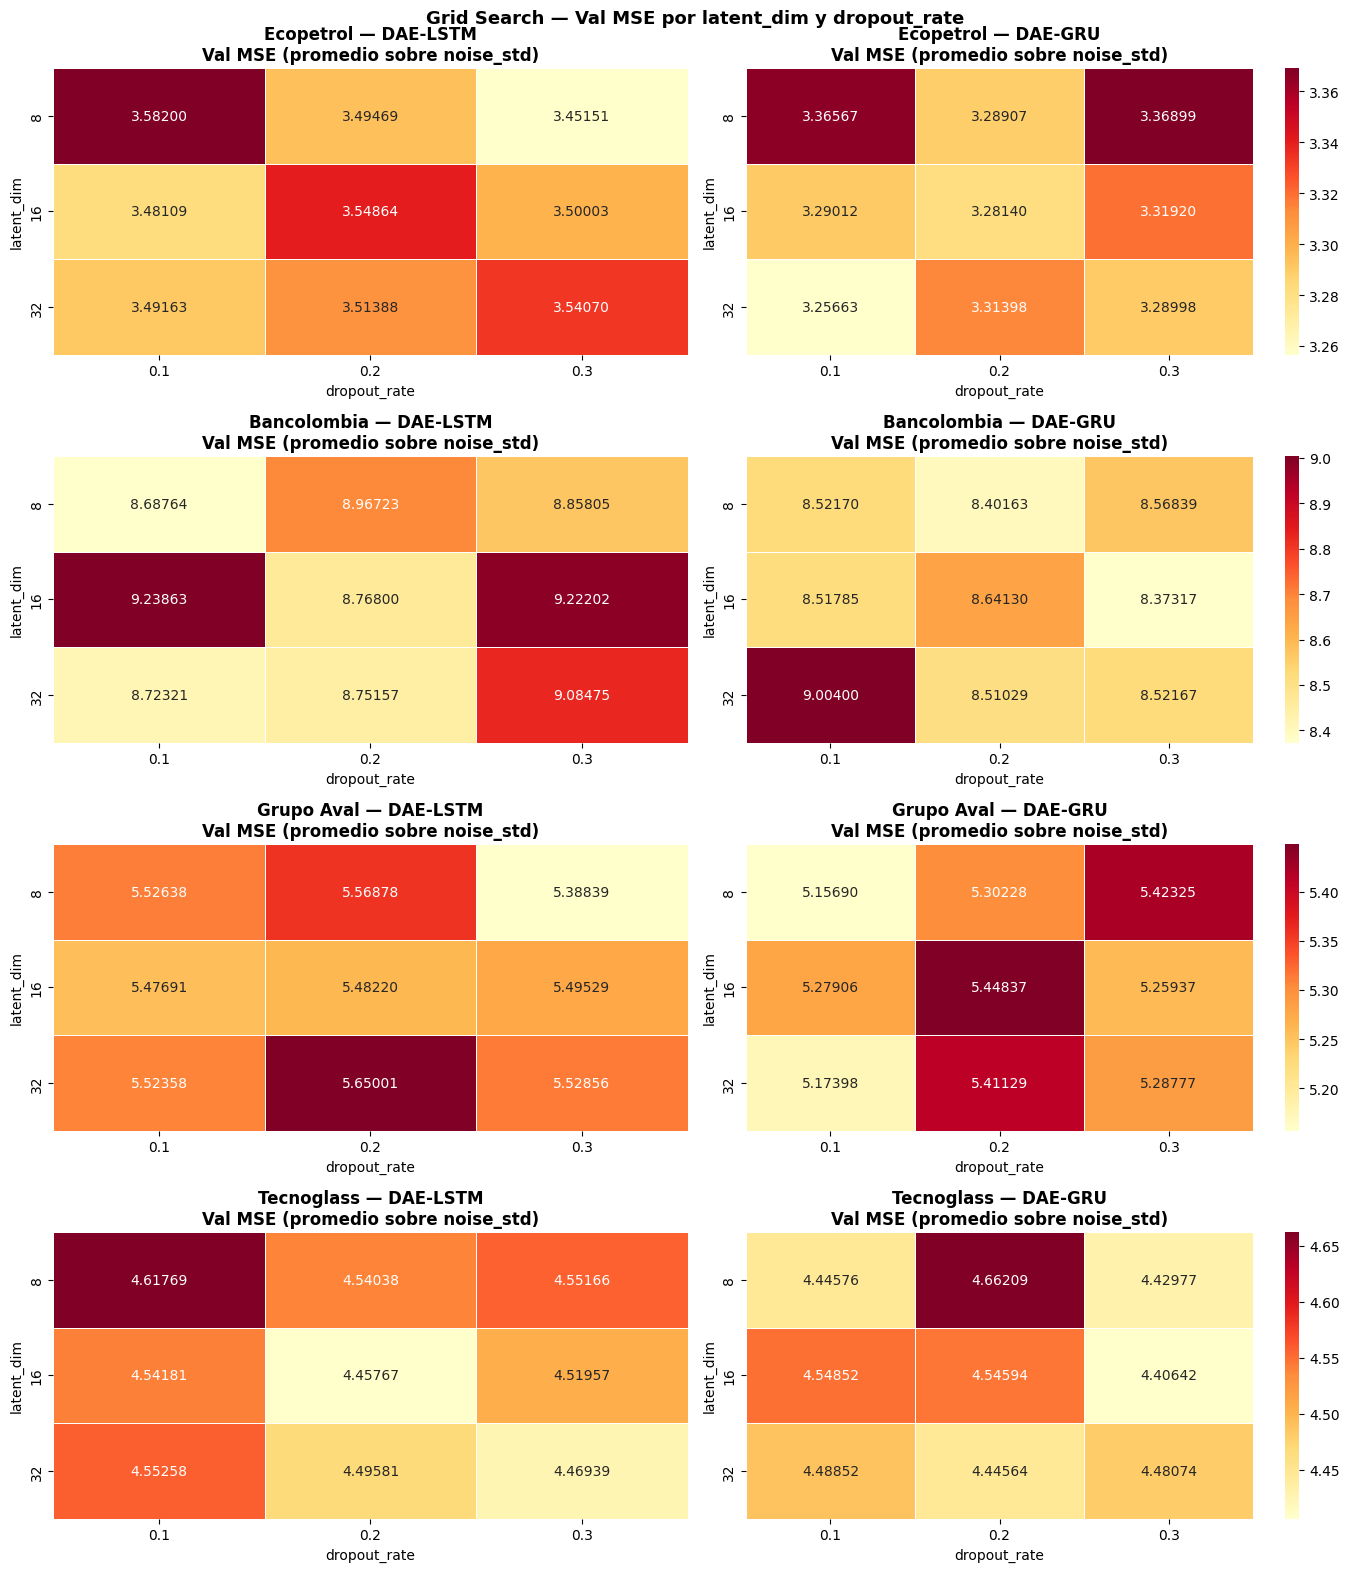

In [16]:
# Visualizacion: heatmap de val_mse por latent_dim y dropout_rate
# promediado sobre noise_std para una vista compacta

fig, axes = plt.subplots(
    len(TICKERS), 2,
    figsize=(14, 4 * len(TICKERS))
)

for i, ticker in enumerate(TICKERS):
    for j, cell_type in enumerate(['LSTM', 'GRU']):
        sub = results_df[
            (results_df['ticker']    == ticker) &
            (results_df['cell_type'] == cell_type)
        ]
        pivot = sub.groupby(
            ['latent_dim', 'dropout_rate']
        )['val_mse'].mean().unstack()

        sns.heatmap(
            pivot, ax=axes[i, j], annot=True, fmt='.5f',
            cmap='YlOrRd', linewidths=0.5,
            cbar=(j == 1)
        )
        axes[i, j].set_title(
            f'{NAMES[ticker]} — DAE-{cell_type}\n'
            f'Val MSE (promedio sobre noise_std)',
            fontweight='bold'
        )
        axes[i, j].set_xlabel('dropout_rate')
        axes[i, j].set_ylabel('latent_dim')

plt.suptitle(
    'Grid Search — Val MSE por latent_dim y dropout_rate',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_grid_search_heatmap.png',
            dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Entrenamiento del Modelo Final

Con la mejor configuracion identificada en el grid search, se re-entrena
cada modelo con mayor numero de epochs y se registran las curvas de
aprendizaje. Se entrenan dos modelos por activo: DAE-LSTM y DAE-GRU.

El modelo final del proyecto sera el que obtenga menor MSE de validacion
entre las dos variantes — decision que se documenta al final de esta seccion.

In [17]:
# Extraer la mejor configuracion por activo y variante
best_configs = {}

for ticker in TICKERS:
    best_configs[ticker] = {}
    for cell_type in ['LSTM', 'GRU']:
        sub  = results_df[
            (results_df['ticker']    == ticker) &
            (results_df['cell_type'] == cell_type)
        ].sort_values('val_mse')
        best = sub.iloc[0]
        best_configs[ticker][cell_type] = {
            'latent_dim':   int(best['latent_dim']),
            'dropout_rate': float(best['dropout_rate']),
            'noise_std':    float(best['noise_std']),
        }

print('MEJORES CONFIGURACIONES POR ACTIVO Y VARIANTE')
print('=' * 65)
for ticker in TICKERS:
    print(f'\n{NAMES[ticker]} ({ticker})')
    for cell_type in ['LSTM', 'GRU']:
        cfg = best_configs[ticker][cell_type]
        print(f'  DAE-{cell_type}: latent_dim={cfg["latent_dim"]}  '
              f'dropout={cfg["dropout_rate"]}  noise={cfg["noise_std"]}')

MEJORES CONFIGURACIONES POR ACTIVO Y VARIANTE

Ecopetrol (EC)
  DAE-LSTM: latent_dim=16  dropout=0.1  noise=0.01
  DAE-GRU: latent_dim=8  dropout=0.2  noise=0.1

Bancolombia (CIB)
  DAE-LSTM: latent_dim=8  dropout=0.1  noise=0.01
  DAE-GRU: latent_dim=32  dropout=0.2  noise=0.1

Grupo Aval (AVAL)
  DAE-LSTM: latent_dim=16  dropout=0.1  noise=0.01
  DAE-GRU: latent_dim=8  dropout=0.1  noise=0.05

Tecnoglass (TGLS)
  DAE-LSTM: latent_dim=32  dropout=0.3  noise=0.01
  DAE-GRU: latent_dim=8  dropout=0.3  noise=0.01


In [18]:
# Entrenamiento final con las mejores configuraciones
EPOCHS_FINAL = 150

trained_models   = {}
training_history = {}

for ticker in TICKERS:
    trained_models[ticker]   = {}
    training_history[ticker] = {}

    for cell_type in ['LSTM', 'GRU']:
        cfg = best_configs[ticker][cell_type]

        print(f'\nEntrenando DAE-{cell_type} — {NAMES[ticker]} ({ticker})')
        print(f'  Config: latent_dim={cfg["latent_dim"]}  '
              f'dropout={cfg["dropout_rate"]}  noise={cfg["noise_std"]}')

        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)
        np.random.seed(SEED)

        X_train = windows[ticker]['train'].astype(np.float32)
        X_val   = windows[ticker]['val'].astype(np.float32)

        X_train_noisy = add_noise(X_train, cfg['noise_std']).astype(np.float32)

        model = build_dae(
            seq_len=SEQ_LEN, n_features=N_FEATURES,
            latent_dim=cfg['latent_dim'],
            dropout_rate=cfg['dropout_rate'],
            cell_type=cell_type,
            name=f'DAE_{cell_type}_{ticker}_final'
        )

        es = callbacks.EarlyStopping(
            monitor='val_loss', patience=15,
            restore_best_weights=True, verbose=0
        )
        lr_scheduler = callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=7, min_lr=1e-5, verbose=0
        )

        history = model.fit(
            x=X_train_noisy,
            y=X_train,
            validation_data=(X_val, X_val),
            epochs=EPOCHS_FINAL,
            batch_size=BATCH_SIZE,
            callbacks=[es, lr_scheduler],
            verbose=1
        )

        # Evaluacion final en validacion (sin ruido)
        X_pred        = model.predict(X_val, verbose=0)
        mse_arr       = np.mean((X_val - X_pred) ** 2, axis=(1, 2))
        val_mse_final = float(np.mean(mse_arr))

        print(f'  Val MSE final: {val_mse_final:.6f}  '
              f'(epochs={len(history.history["loss"])}')

        trained_models[ticker][cell_type]   = model
        training_history[ticker][cell_type] = history.history


Entrenando DAE-LSTM — Ecopetrol (EC)
  Config: latent_dim=16  dropout=0.1  noise=0.01
Epoch 1/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - loss: 0.7978 - val_loss: 4.0517 - learning_rate: 0.0010
Epoch 2/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.7233 - val_loss: 3.7441 - learning_rate: 0.0010
Epoch 3/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.6977 - val_loss: 3.6695 - learning_rate: 0.0010
Epoch 4/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.6855 - val_loss: 3.7749 - learning_rate: 0.0010
Epoch 5/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.6692 - val_loss: 3.8297 - learning_rate: 0.0010
Epoch 6/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.6567 - val_loss: 3.7939 - learning_rate: 0.0010
Epoch 7/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.6485 - val_loss: 3.6069 - learning_rate: 0.0010
Epoch 8/150
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.6416 - val_loss: 3.6219 - learning_rate: 0.0010
Epoch 9/150
38/38 ━━━━━━━━━━━━━━━

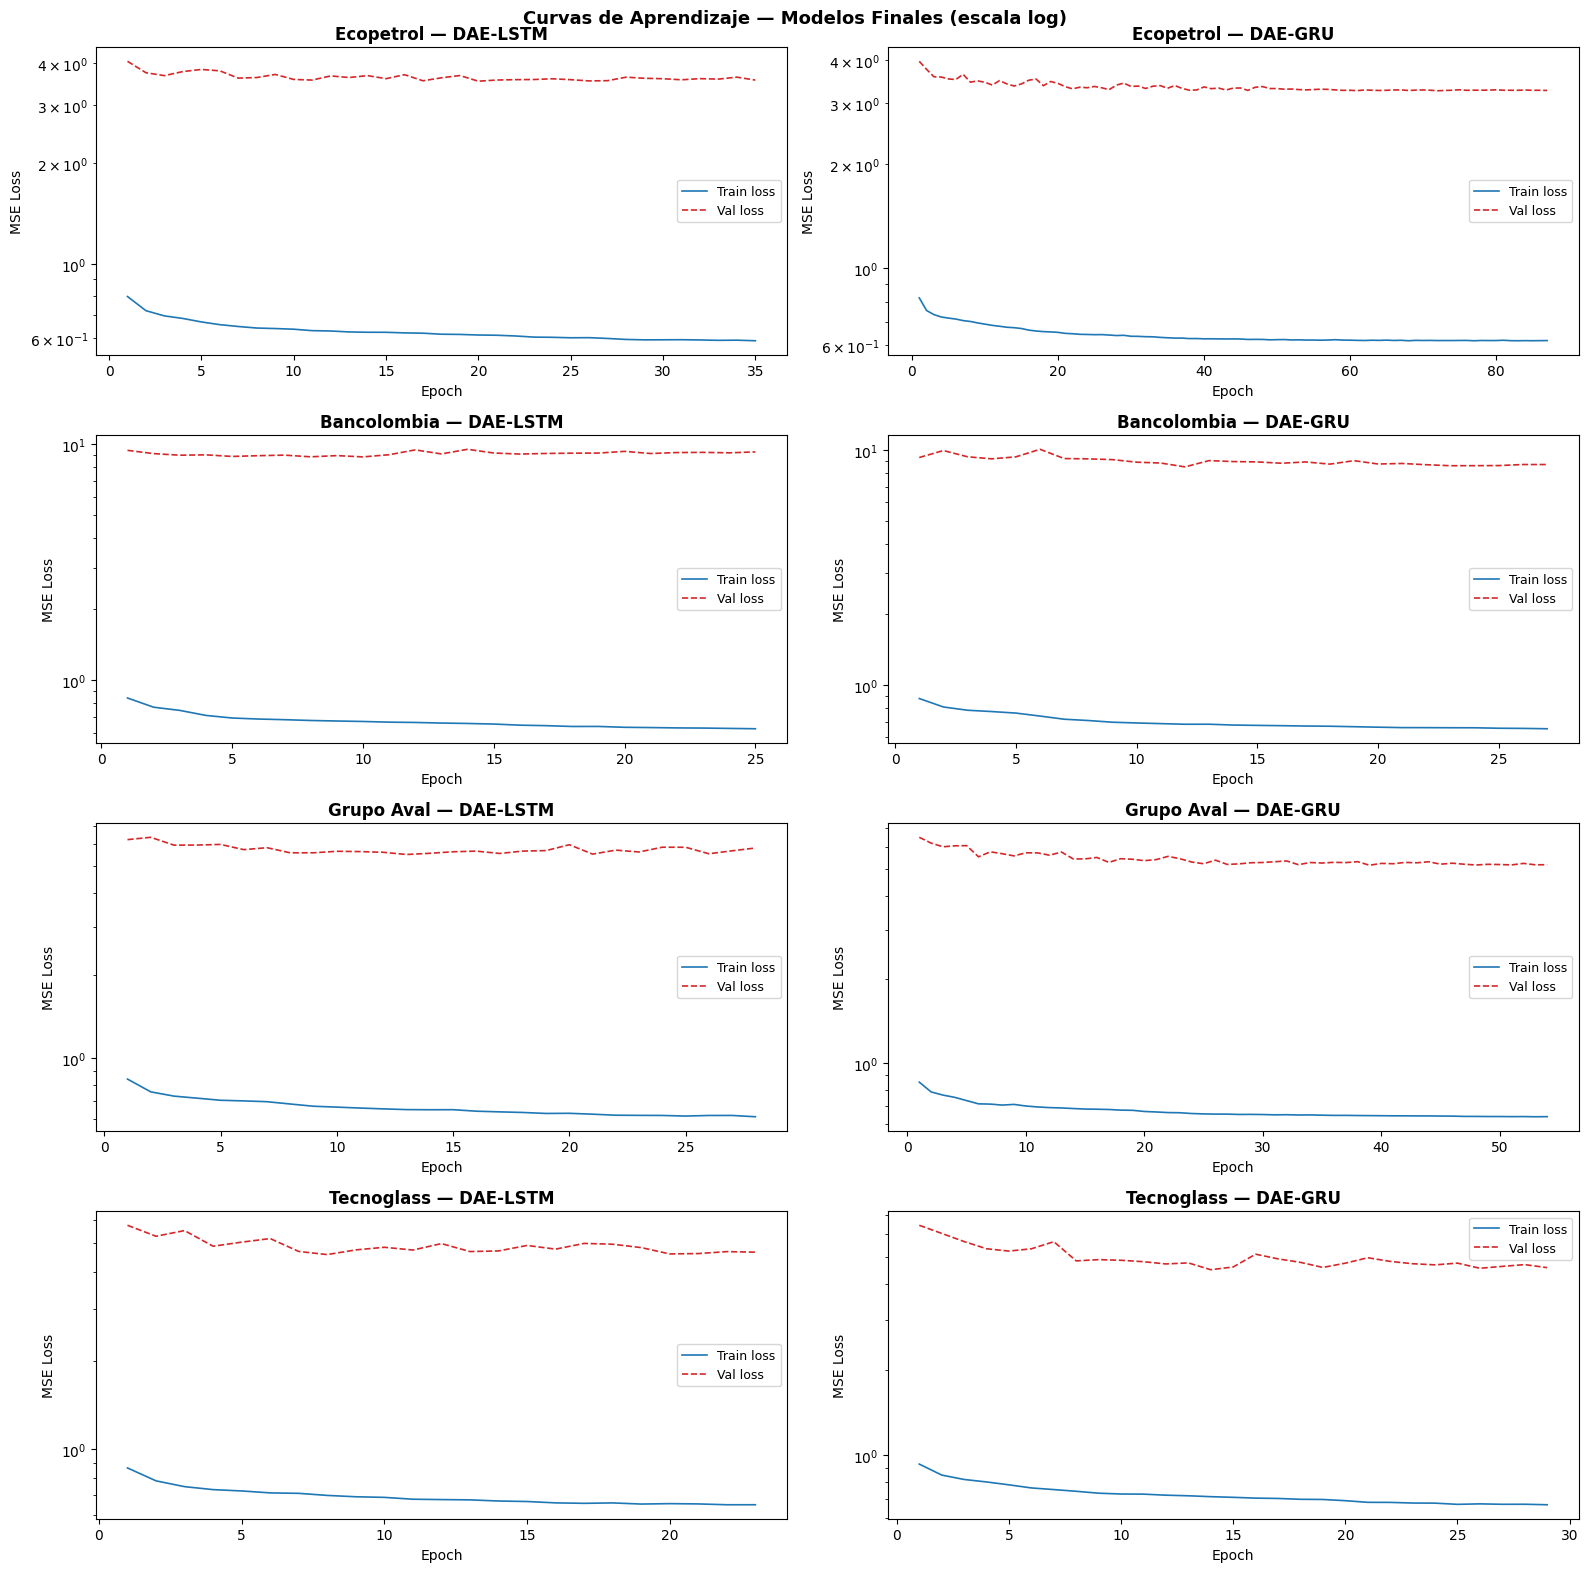

In [19]:
# Curvas de aprendizaje — train loss vs val loss
fig, axes = plt.subplots(
    len(TICKERS), 2,
    figsize=(16, 4 * len(TICKERS)), sharex=False
)

for i, ticker in enumerate(TICKERS):
    for j, cell_type in enumerate(['LSTM', 'GRU']):
        hist = training_history[ticker][cell_type]
        ep   = range(1, len(hist['loss']) + 1)

        axes[i, j].plot(ep, hist['loss'],
                        label='Train loss', color='#1f77b4', linewidth=1.2)
        axes[i, j].plot(ep, hist['val_loss'],
                        label='Val loss', color='#d62728',
                        linewidth=1.2, linestyle='--')
        axes[i, j].set_title(
            f'{NAMES[ticker]} — DAE-{cell_type}',
            fontweight='bold'
        )
        axes[i, j].set_xlabel('Epoch')
        axes[i, j].set_ylabel('MSE Loss')
        axes[i, j].legend(fontsize=9)
        axes[i, j].set_yscale('log')

plt.suptitle(
    'Curvas de Aprendizaje — Modelos Finales (escala log)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'fig_curvas_aprendizaje.png',
            dpi=120, bbox_inches='tight')
plt.show()

In [22]:
# Comparacion DAE-LSTM vs DAE-GRU por activo
print('COMPARACION FINAL: DAE-LSTM vs DAE-GRU')
print('=' * 65)
print(f"{'Activo':<14}  {'DAE-LSTM val_mse':>18}  "
      f"{'DAE-GRU val_mse':>18}  {'Ganador':>10}")
print('-' * 65)

winner_summary = {}

for ticker in TICKERS:
    X_val = windows[ticker]['val'].astype(np.float32)

    mse_lstm = compute_val_mse(trained_models[ticker]['LSTM'], X_val)
    mse_gru  = compute_val_mse(trained_models[ticker]['GRU'],  X_val)

    winner = 'DAE-LSTM' if mse_lstm <= mse_gru else 'DAE-GRU'
    winner_summary[ticker] = {
        'winner':   winner,
        'mse_lstm': mse_lstm,
        'mse_gru':  mse_gru,
    }

    print(f"{NAMES[ticker]:<14}  {mse_lstm:>18.6f}  "
          f"{mse_gru:>18.6f}  {winner:>10}")

print()
print('Nota: el modelo con menor Val MSE se reporta como modelo final.')
print('Esta decision es vinculante para NB6 (evaluacion) y NB7 (tests estadisticos).')

COMPARACION FINAL: DAE-LSTM vs DAE-GRU
Activo            DAE-LSTM val_mse     DAE-GRU val_mse     Ganador
-----------------------------------------------------------------
Ecopetrol                 3.531361            3.259856     DAE-GRU
Bancolombia               8.849927            8.486879     DAE-GRU
Grupo Aval                5.514574            5.150609     DAE-GRU
Tecnoglass                4.580633            4.502861     DAE-GRU

Nota: el modelo con menor Val MSE se reporta como modelo final.
Esta decision es vinculante para NB6 (evaluacion) y NB7 (tests estadisticos).


---
## 5. Exportacion de Modelos Entrenados

Se exportan todos los modelos entrenados (DAE-LSTM y DAE-GRU por activo)
en formato `.keras` para uso en NB4, NB6 y NB7. Adicionalmente se exporta
el resumen de la busqueda de hiperparametros y la tabla de ganadores.

In [23]:
# Exportar modelos en formato .keras
print('EXPORTACION DE MODELOS')
print('=' * 65)

for ticker in TICKERS:
    for cell_type in ['LSTM', 'GRU']:
        model    = trained_models[ticker][cell_type]
        filename = AE_PATH / f'DAE_{cell_type}_{ticker}.keras'
        model.save(filename)
        size = filename.stat().st_size / 1024
        print(f'  Guardado: {filename.name:<35} {size:>8.1f} KB')

EXPORTACION DE MODELOS
  Guardado: DAE_LSTM_EC.keras                      792.3 KB
  Guardado: DAE_GRU_EC.keras                       608.4 KB
  Guardado: DAE_LSTM_CIB.keras                     777.2 KB
  Guardado: DAE_GRU_CIB.keras                      644.7 KB
  Guardado: DAE_LSTM_AVAL.keras                    792.3 KB
  Guardado: DAE_GRU_AVAL.keras                     608.4 KB
  Guardado: DAE_LSTM_TGLS.keras                    822.5 KB
  Guardado: DAE_GRU_TGLS.keras                     608.4 KB


In [24]:
# Exportar resultados del grid search
results_df.to_csv(AE_PATH / 'grid_search_results.csv', index=False)
print(f'Grid search guardado: {AE_PATH / "grid_search_results.csv"}')

# Exportar tabla de ganadores
winner_df = pd.DataFrame([
    {
        'Activo':       NAMES[t],
        'Ticker':       t,
        'Val MSE LSTM': winner_summary[t]['mse_lstm'],
        'Val MSE GRU':  winner_summary[t]['mse_gru'],
        'Modelo Final': winner_summary[t]['winner'],
    }
    for t in TICKERS
])

winner_df.to_csv(AE_PATH / 'model_selection.csv', index=False)

print(f'Seleccion guardada : {AE_PATH / "model_selection.csv"}')
print()
print('RESUMEN FINAL')
print('=' * 65)
print(winner_df.to_string(index=False))
print()
print('Artefactos disponibles para NB4, NB6 y NB7:')
print(f'  Modelos   : {AE_PATH}/*.keras')
print(f'  Grid CSV  : {AE_PATH}/grid_search_results.csv')
print(f'  Seleccion : {AE_PATH}/model_selection.csv')

Grid search guardado: C:\2026-10\DEEP LEARNING\anomaly-detection-colombian-stocks-autoencoder\models\autoencoder\grid_search_results.csv
Seleccion guardada : C:\2026-10\DEEP LEARNING\anomaly-detection-colombian-stocks-autoencoder\models\autoencoder\model_selection.csv

RESUMEN FINAL
     Activo Ticker  Val MSE LSTM  Val MSE GRU Modelo Final
  Ecopetrol     EC      3.531361     3.259856      DAE-GRU
Bancolombia    CIB      8.849927     8.486879      DAE-GRU
 Grupo Aval   AVAL      5.514574     5.150609      DAE-GRU
 Tecnoglass   TGLS      4.580633     4.502861      DAE-GRU

Artefactos disponibles para NB4, NB6 y NB7:
  Modelos   : C:\2026-10\DEEP LEARNING\anomaly-detection-colombian-stocks-autoencoder\models\autoencoder/*.keras
  Grid CSV  : C:\2026-10\DEEP LEARNING\anomaly-detection-colombian-stocks-autoencoder\models\autoencoder/grid_search_results.csv
  Seleccion : C:\2026-10\DEEP LEARNING\anomaly-detection-colombian-stocks-autoencoder\models\autoencoder/model_selection.csv
